# Transformer代码复现

## Prelims

In [1]:
# -*- coding: utf-8 -*-
# !pip install -r requirements.txt
# # Uncomment for colab
# #
# !pip install -q torchdata==0.3.0 torchtext==0.12 spacy==3.2 altair GPUtil
# !python -m spacy download de_core_news_sm
# !python -m spacy download en_core_web_sm

In [2]:
import os
from os.path import exists
import torch
import torch.nn as nn
from torch.nn.functional import log_softmax, pad
# import torch.nn.functional as F
import math
import copy
import time
from torch.optim.lr_scheduler import LambdaLR
import pandas as pd
import altair as alt
# from torchtext.data.functional import to_map_style_dataset
from torch.utils.data import DataLoader
# from torchtext.vocab import build_vocab_from_iterator
# import torchtext.datasets as datasets
import spacy
import GPUtil
import warnings
from torch.utils.data.distributed import DistributedSampler
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP


# Set to False to skip notebook execution (e.g. for debugging)
warnings.filterwarnings("ignore")
RUN_EXAMPLES = True

In [3]:
# Some convenience helper functions used throughout the notebook


def is_interactive_notebook():
    return __name__ == "__main__"


def show_example(fn, args=[]):
    if __name__ == "__main__" and RUN_EXAMPLES:
        return fn(*args)


def execute_example(fn, args=[]):
    if __name__ == "__main__" and RUN_EXAMPLES:
        fn(*args)


class DummyOptimizer(torch.optim.Optimizer):
    def __init__(self):
        self.param_groups = [{"lr": 0}]
        None

    def step(self):
        None

    def zero_grad(self, set_to_none=False):
        None


class DummyScheduler:
    def step(self):
        None

## Encoder-Decoder架构及其代码实现
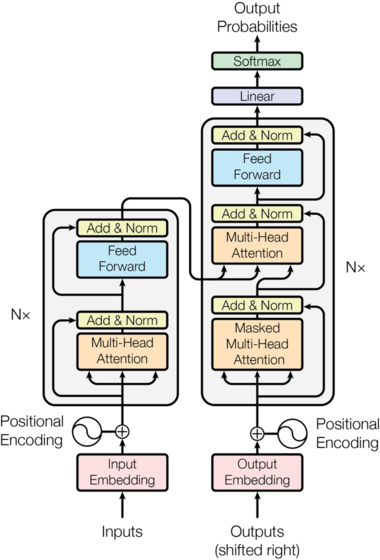

Encoder-Decoder即为transformer的整体架构

In [4]:
class EncoderDecoder(nn.Module):
    """
        一个标准的编码器-解码器结构。编码器负责处理输入序列，解码器负责生成输出序列。
        @param encoder: 编码器模块，负责将输入序列编码成上下文表示
        @param decoder: 解码器模块，负责根据编码器的输出生成目标序列
        @param src_embed: 输入序列的嵌入层，负责将输入序列转换为向量表示
        @param tgt_embed: 目标序列的嵌入层，负责将目标序列转换为向量表示
        @param generator: 生成器模块，负责将解码器的输出转换为最终的预测结果
    """
    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.generator = generator

    def forward(self, src, tgt, src_mask, tgt_mask):
        """前向传播函数，接受输入序列、目标序列以及对应的掩码，并返回解码器的输出。"""
        return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)
    
    def encode(self, src, src_mask):
        """解码器函数，接受输入序列和对应的掩码，并返回编码器的输出。"""
        return self.encoder(self.src_embed(src), src_mask)
    
    def decode(self, memory, src_mask, tgt, tgt_mask):
        """编码器函数，接受编码器的输出、输入序列的掩码、目标序列和目标序列的掩码，并返回解码器的输出。"""
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)

In [5]:
class Generator(nn.Module):
    """
        生成器模块，负责将解码器的输出转换为最终的预测结果。
        @param d_model: 模型的维度，通常与解码器的输出维度相同
        @param vocab: 词汇表的大小，决定了最终预测结果的维度
    """
    def __init__(self, d_model, vocab):
        super(Generator, self).__init__()
        self.proj = nn.Linear(d_model, vocab)

    def forward(self, x):
        """前向传播函数，接受解码器的输出，并返回经过线性变换和log_softmax处理后的预测结果。"""
        return log_softmax(self.proj(x), dim=-1)

## Encoder和Decoder

编码器和解码器，编码器用于输出一组上下文关系，供解码器使用。
解码器输出的是最终序列。

### Encoder

In [6]:
# LayerNorm层的实现，提供了对输入进行层归一化的功能
class LayerNorm(nn.Module):
    """
        @param features: 输入特征的维度，决定了缩放和偏移参数的大小
        @param eps: 一个小的epsilon值，用于防止在计算标准差时出现除以零的情况
    """
    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()  # 初始化LayerNorm类，接受特征维度和一个小的epsilon值作为参数
        self.a_2 = nn.Parameter(torch.ones(features))  # 可学习的缩放参数，初始化为全1
        self.b_2 = nn.Parameter(torch.zeros(features)) # 可学习的偏移参数，初始化为全0
        self.eps = eps  # epsilon值，用于防止除以零的情况

    def forward(self, x):
        """前向传播函数，接受输入张量x，并对其进行层归一化处理。"""
        mean = x.mean(-1, keepdim=True)  # 计算输入张量在最后一个维度上的均值
        std = x.std(-1, keepdim=True)    # 计算输入张量在最后一个维度上的标准差
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2  # 对输入进行归一化，并应用可学习的缩放和偏移参数

In [7]:
def clones(module, N):
    """生成N个相同的模块副本。"""
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])


class Encoder(nn.Module):
    """
        编码器模块，负责将输入序列编码成上下文表示
        @param layers：编码器层的列表，构成完整的编码器堆叠
        @param N：编码器层的数量，决定了编码器的深度
        @param mask：输入序列的掩码，用于在编码过程中屏蔽掉不需要关注的部分（如填充标记）
    """
    def __init__(self, layer, N):
        super(Encoder, self).__init__() # 初始化编码器类，接受一个编码器层和层数N作为参数
        self.layers = clones(layer, N)  # 使用clones函数创建N个相同的编码器层副本，构成完整的编码器堆叠
        self.norm = nn.LayerNorm(layer.size)    # 对编码器的输出进行层归一化，确保输出的稳定性和训练的收敛性

    def forward(self, x, mask):
        """前向传播函数，接受输入序列和对应的掩码，并依次通过每个编码器层进行处理，最后返回经过层归一化处理的输出。"""
        for layer in self.layers:
            x = layer(x, mask)  # 依次通过每个编码器层进行处理
        return self.norm(x)    # 对最终的输出进行层归一化并返回

每层的输出为

$$ LayerNorm(X + SubLayer(X)) $$

In [8]:
class SublayerConnection(nn.Module):
    """
        子层连接模块，用于在Transformer模型中连接不同的子层
        @param size: 输入特征的维度，决定了层归一化和dropout的参数大小
        @param dropout: dropout率，用于在子层连接中进行正则化，防止过拟合
    """
    def __init__(self, size, dropout):
        super(SublayerConnection, self).__init__()  # 初始化SublayerConnection类，接受特征维度和dropout率作为参数
        self.norm = LayerNorm(size)  # 使用LayerNorm进行层归一化，确保子层连接的输出稳定
        self.dropout = nn.Dropout(dropout)  # 使用Dropout进行正则化，防止过拟合

    def forward(self, x, sublayer):
        """前向传播函数，接受输入张量x和一个子层函数sublayer，并返回经过子层处理和dropout后的结果。"""
        return x + self.dropout(sublayer(self.norm(x)))  # 对输入进行层归一化，传入子层函数进行处理，然后应用dropout，并将结果与输入相加实现残差连接


dropout正则化：训练时“丢掉”一部分神经元，防止过拟合。

### EncoderLayer
即论文中左侧的编码器，由两层组成，第一层是多头注意力机制层，第二层是一个FFN

In [9]:
class EncoderLayer(nn.Module):
    def __init__(self, size, self_attn, feed_forward, dropout):
        super(EncoderLayer, self).__init__()  # 初始化EncoderLayer类，接受特征维度、注意力机制、前馈网络和dropout率作为参数
        self.self_attn = self_attn  # 自注意力机制，用于捕捉输入序列中不同位置之间的依赖关系
        self.feed_forward = feed_forward  # 前馈网络，用于对自注意力的输出进行进一步处理
        self.sublayer = clones(SublayerConnection(size, dropout), 2)  # 创建两个子层连接，分别用于自注意力和前馈网络
        self.size = size  # 存储特征维度信息

    def forward(self, x, mask):
        """前向传播函数，接受输入张量x和对应的掩码，并依次通过自注意力机制和前馈网络进行处理，最后返回处理后的结果。"""
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))  # 首先通过第一个子层连接处理输入，使用自注意力机制进行计算
        return self.sublayer[1](x, self.feed_forward)  # 然后通过第二个子层连接处理自注意力的输出，使用前馈网络进行计算，并返回最终结果

## Decoder 解码器
一般由N=6个相同的子层组成

In [10]:
class Decoder(nn.Module):
    """
        解码器模块，根据编码器的输出生成目标序列
        @param layer：单个解码器层，包含自注意力机制、编码器-解码器注意力机制和前馈网络
        @param N：解码器层的数量，决定了解码器的深度
    """
    def __init__(self, layer, N=6):
        super(Decoder, self).__init__()  # 初始化Decoder类，接受一个解码器层和层数N作为参数
        self.layers = clones(layer, N)  # 使用clones函数创建N个相同的解码器层副本，构成完整的解码器堆叠
        self.norm = nn.LayerNorm(layer.size)    # 对解码器的输出进行层归一化，确保输出的稳定性和训练的收敛性

    def forward(self, x, memory, src_mask, tgt_mask):
        """前向传播函数"""
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)  # 依次通过每个解码器层进行处理
        return self.norm(x)    # 对最终的输出进行层归一化并返回
    

class DecoderLayer(nn.Module):
    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 3)

    def forward(self, x, memory, src_mask, tgt_mask):
        m = memory
        x = self.sublayer[0](x, lambda x:self.self_attn(x, x, x, tgt_mask))
        x = self.sublayer[1](x, lambda x:self.src_attn(x, m, m, src_mask))
        return self.sublayer[2](x, self.feed_forward)
         

在解码器中，自注意力子层必须使用 **因果掩码（look-ahead mask）**，使位置 $t$ 只能关注到历史位置（$j \le t$），而不能看到未来词。这样可以避免训练时“偷看答案”，并保证训练阶段与推理阶段（逐步生成下一个词）的信息流一致。

常见实现是先在注意力分数上加掩码：
$$
\mathrm{Attention}(Q,K,V)
= \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V ,
$$
其中掩码矩阵 $M$ 定义为
$$
M_{t,j}=
\begin{cases}
0, & j \le t,\\
-\infty, & j > t.
\end{cases}
$$

因此对每个位置 $t$，softmax 后有
$$
\alpha_{t,j}=0 \quad (j>t),
$$
从而彻底屏蔽未来位置的干扰。

In [11]:
def subsequent_mask(size):
    """标记出序列中每个位置可以关注的位置"""
    attn_shape = (1, size, size)
    subsequent_mask = torch.triu(torch.ones(attn_shape), diagonal=1).type(torch.uint8)  # 创建一个上三角矩阵，标记出每个位置可以关注的位置
    # torch.triu是创建一个上三角矩阵的函数，torch.ones创建一个全1的张量，diagonal=1表示从主对角线开始向上偏移一行
    return subsequent_mask == 0


def show_subsequent_mask(size):
    mask = subsequent_mask(size)[0]
    print(mask.int())

show_subsequent_mask(5)

tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1]], dtype=torch.int32)


## 自注意力机制的实现
$$
\mathrm{Attention}(Q,K,V)
= \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V ,
$$

softmax处理是对每一行进行softmax

In [12]:
def attention(query, key, value, mask=None, dropout=None):
    """计算注意力权重并用于值向量"""
    d_k = query.size(-1)    # 获取查询向量的维度，-1表示是最后一个维度的大小
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)    # 计算注意力分散，即上述公式中softmax()中的部分。注意key.transpose(-2, -1)是转置
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)  # 如果提供了掩码，将掩码位置的分数设置为一个非常小的值，确保这些位置在softmax中几乎没有权重，掩码的部分同以上笔记
    p_attn = torch.softmax(scores, dim=-1)  # 对分数进行softmax处理，得到注意力权重
    if dropout is not None:
        p_attn = dropout(p_attn)  # 如果提供了dropout，则对注意力权重进行dropout处理，进一步增强模型的泛化能力
    return torch.matmul(p_attn, value), p_attn  # 将注意力权重应用于值向量，并返回加权后的结果和注意力权重


## Multi-Headed Self-Attention 多头注意力机制的实现

---

给定输入 $X \in \mathbb{R}^{n \times d_{model}}$，不是只做一次 Attention，而是并行做 $h$ 次：

$$
\text{head}_i = \mathrm{Attention}(Q_i,K_i,V_i)
$$

其中：
$$
Q_i = XW_i^Q,\quad K_i = XW_i^K,\quad V_i = XW_i^V
$$

每个头都有自己的一组参数矩阵 $W_i^Q, W_i^K, W_i^V$。

---

把所有头输出在最后一维拼接：

$$
\mathrm{Concat}(\text{head}_1,\dots,\text{head}_h) \in \mathbb{R}^{n \times (h\cdot d_v)}
$$

再经过输出投影矩阵 $W^O$：

$$
\mathrm{MultiHead}(X)=\mathrm{Concat}(\text{head}_1,\dots,\text{head}_h)W^O
$$

通常 $h\cdot d_v=d_{model}$，所以输出维度仍回到 $d_{model}$。

---

```python
self.linears = clones(nn.Linear(d_model, d_model), 4)
```

在线性层 nn.Linear(in_features, out_features) 里，计算是：

[
y = xW^T + b
]

作用：把输入特征做可学习的仿射变换，改变表示空间。

unsqueeze(1)是对Tensor的操作，用于在第二个维度插入一个新维度
```python
x = torch.randn(2, 3)
print(x.shape)         # torch.Size([2, 3])
y = x.unsqueeze(1)
print(y.shape)         # torch.Size([2, 1, 3])
```

lin(x)：先用线性层变换输入，输出形状一般是 [batch, seq_len, d_model]

.view(nbatches, -1, self.h, self.d_k)：把 d_model 拆成 h 个头，每头维度 d_k，变成 [batch, seq_len, h, d_k]

nbatches：batch size

-1：自动推断序列长度

self.h：头数

self.d_k：每头的维度

.transpose(1, 2)：交换第 2、3 维，变成 [batch, h, seq_len, d_k]，方便后续并行计算每个头的注意力

In [13]:
class MultiHeadedAttention(nn.Module):
    """
        多头注意力机制模块
        @param h: 注意力头的数量，决定了模型能够捕捉到的不同子空间的依赖关系数量
        @param d_model: 模型的维度，通常与输入和输出的特征维度相同
        @param dropout: dropout率，用于在注意力机制中进行正则化，防止过拟合
    """
    def __init__(self, h, d_model, dropout=0.1):
        super(MultiHeadedAttention, self).__init__()  # 初始化MultiHeadedAttention类，接受注意力头数量、模型维度和dropout率作为参数
        assert d_model % h == 0 # "d_model必须能够被h整除"  assert类似于try...except
        self.d_k = d_model // h  # 每个注意力头的维度
        self.h = h
        self.linears = clones(nn.Linear(d_model, d_model), 4)  # 创建4个线性层，分别用于查询、键、值和输出的线性变换
        self.attn = None    # 接受注意力权重 attn即attention
        self.dropout = nn.Dropout(p=dropout)  # 使用Dropout进行正则化

    def forward(self, query, key, value, mask = None):
        """
            前向传播函数
            @param mask：掩码张量
        """
        if mask is not None:
            mask = mask.unsqueeze(1)  # 在掩码张量的第二个维度上添加一个维度，以便在后续计算中正确广播
        nbatches = query.size(0)    # 获取批次大小，大小为输入的query的第一个维度，batch：批次
        # 1) 线性变换并分割成h个头
        query, key, value = [lin(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2) 
                             for lin, x in zip(self.linears, (query, key, value))]  
            # 对查询、键和值进行线性变换，并将结果分割成h个头
        # 2) 应用注意力机制
        x, self.attn = attention(query, key, value, mask=mask, dropout=self.dropout)  # 计算注意力权重并应用于值向量
        # 3) 连接头并进行最终线性变换
        x = x.transpose(1, 2).contiguous().view(nbatches, -1, self.h * self.d_k)  # 将多头的输出连接起来
        # 释放内存
        del query, key, value  # 删除中间变量，释放内存
        return self.linears[-1](x)  # 通过最后一个线性层进行变换，得到最终的输出
    

### Position-wise Feed-Forward Networks 逐位置前馈网络

这个前馈网络带了ReLu函数，以学习非线性关系

$$ FFN(x) = max(0, {W_1}x + b_1)W_2 + b_2 $$

输入输出维度一般为$d_{model} = 512$，模型中的维度为$d_{ff} = 2048$，用以在更高维空间中处理非线性关系

代码中运用了dropout层，这个在第一层和第二层之间用于丢弃部分神经元防止过拟合

In [14]:
class PositionwizeFeedForward(nn.Module):
    """
        逐位置前馈网络
        用以对每个位置的token进行独立的非线性变换
    """
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwizeFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)  # 第一个线性层，将输入维度从d_model变换到d_ff
        self.w_2 = nn.Linear(d_ff, d_model)  # 第二个线性层，将维度从d_ff变换回d_model
        self.dropout = nn.Dropout(dropout)  # 使用Dropout进行正则化，防止过拟合

    def forward(self, x):
        # 前向传播函数，接受输入张量x，依次通过两个线性层和ReLU激活函数进行处理，并应用dropout，最后返回结果
        return self.w_2(self.dropout(torch.relu(self.w_1(x))))  

### Embeeding 嵌入层

将输入的token转为向量表示，注意为了数值稳定，输出向量需要乘以$ \sqrt{d_{model}} $

In [15]:
class Embeeding(nn.Module):
    """
        嵌入层模块，负责将输入序列转换为向量表示
        @param d_model: 模型的维度，决定了嵌入向量的维度
        @param vocab: 词汇表的大小，决定了嵌入矩阵的行数
    """
    def __init__(self, d_model, vocab):
        super(Embeeding, self).__init__() 
        self.lut = nn.Embedding(vocab, d_model)  # 创建一个嵌入层，将词汇表中的每个词映射到一个d_model维的向量空间中
        self.d_model = d_model  # 存储模型维度信息

    def forward(self, x):
        """前向传播函数，接受输入张量x，并返回对应的嵌入向量，同时对嵌入结果进行缩放处理。"""
        return self.lut(x) * math.sqrt(self.d_model)  # 将输入张量通过嵌入层转换为向量表示，并乘以sqrt(d_model)进行缩放处理，以保持数值稳定性

### Positional Encoding 位置编码

用于将输入序列中的词赋予位置编码

在*Attention is All You Need*论文中，位置编码的公式由以下式子赋予：

$$
\begin{split}
PE_{(pos,2i)}&=sin(\frac{pos}{10000^{\frac{2i}{dmodel}}})\\
PE_{(pos,2i+1)}&=cos⁡(\frac{pos}{10000^\frac{2i}{dmodel}})
\end{split}
$$

In [16]:
class PositionalEncoding(nn.Module):
    """
    位置编码模块（Sinusoidal Positional Encoding）
    输入输出形状: [batch_size, seq_len, d_model]
    """
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # 计算位置编码
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]

        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)].requires_grad_(False)  # 将位置编码添加到输入嵌入上，确保位置编码不参与梯度计算
        return self.dropout(x)

### make_model() 模型构建
构建一个Transformer

In [17]:
def make_model(src_vocab, tgt_vocab, N=6, d_model=512, d_ff=2048, h=8, dropout=0.1):
    """构建Transformer模型"""
    c = copy.deepcopy
    attn = MultiHeadedAttention(h, d_model, dropout)    # 构建一个多头注意力机制层
    ff = PositionwizeFeedForward(d_model, d_ff, dropout)    # 构建一个前馈神经网络层
    position = PositionalEncoding(d_model, dropout)    # 构建一个位置编码层
    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff), dropout), N),
        nn.Sequential(Embeeding(d_model, src_vocab), c(position)),
        nn.Sequential(Embeeding(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab)
    )

    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)  # 对模型参数进行Xavier均匀初始化，以提高训练的稳定性和收敛速度

    return model

## Model Trainning Example

In [23]:
# ...existing code...

import torch
import torch.nn as nn

def make_std_mask(tgt, pad=0):
    """
    tgt: [batch, tgt_len]
    返回解码器mask: padding mask & subsequent mask
    """
    tgt_mask = (tgt != pad).unsqueeze(-2)  # [batch, 1, tgt_len]
    tgt_mask = tgt_mask & subsequent_mask(tgt.size(-1)).to(tgt.device)
    return tgt_mask

def train_example(
    num_steps=1000,
    batch_size=32,
    seq_len=12,
    vocab_size=100,
    lr=1e-3,
    pad_id=0,
    device=None,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # 建一个小模型，训练更快
    model = make_model(
        src_vocab=vocab_size,
        tgt_vocab=vocab_size,
        N=2,
        d_model=128,
        d_ff=512,
        h=4,
        dropout=0.1,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.98), eps=1e-9)
    criterion = nn.NLLLoss(ignore_index=pad_id)

    model.train()
    for step in range(1, num_steps + 1):
        # 1) 造一批 toy 数据（copy task）
        src = torch.randint(1, vocab_size, (batch_size, seq_len), device=device)
        tgt = src.clone()

        # 2) teacher forcing：输入去掉最后一个，标签去掉第一个
        tgt_input = tgt[:, :-1]
        tgt_y = tgt[:, 1:]

        # 3) 构建 mask
        src_mask = (src != pad_id).unsqueeze(-2)            # [batch, 1, src_len]
        tgt_mask = make_std_mask(tgt_input, pad=pad_id)     # [batch, tgt_len, tgt_len]

        # 4) 前向 + 损失
        out = model(src, tgt_input, src_mask, tgt_mask)     # [batch, tgt_len, d_model]
        log_probs = model.generator(out)                    # [batch, tgt_len, vocab]
        loss = criterion(
            log_probs.reshape(-1, vocab_size),
            tgt_y.reshape(-1)
        )

        # 5) 反向传播
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        if step % 20 == 0 or step == 1:
            print(f"step={step:4d} | loss={loss.item():.4f}")

        # if step % 300 == 0:
        #     lr /= 2  # 每100步将学习率减半
        #     optimizer.param_groups[0]['lr'] = lr  # 更新优化器的学习率

    return model

# 运行示例
trained_model = train_example()

step=   1 | loss=5.1534
step=  20 | loss=4.5935
step=  40 | loss=4.4425
step=  60 | loss=4.1733
step=  80 | loss=3.8772
step= 100 | loss=3.5677
step= 120 | loss=3.0339
step= 140 | loss=2.5184
step= 160 | loss=1.8511
step= 180 | loss=1.6124
step= 200 | loss=1.0795
step= 220 | loss=0.9740
step= 240 | loss=0.8239
step= 260 | loss=0.6544
step= 280 | loss=0.7654
step= 300 | loss=0.5550
step= 320 | loss=0.4864
step= 340 | loss=0.4929
step= 360 | loss=0.4012
step= 380 | loss=0.4089
step= 400 | loss=0.3536
step= 420 | loss=0.3567
step= 440 | loss=0.3969
step= 460 | loss=0.3884
step= 480 | loss=0.3254
step= 500 | loss=0.1782
step= 520 | loss=0.3080
step= 540 | loss=0.2952
step= 560 | loss=0.3143
step= 580 | loss=0.2366
step= 600 | loss=0.1778
step= 620 | loss=0.2009
step= 640 | loss=0.1557
step= 660 | loss=0.1231
step= 680 | loss=0.2042
step= 700 | loss=0.1037
step= 720 | loss=0.1670
step= 740 | loss=0.1639
step= 760 | loss=0.1689
step= 780 | loss=0.2139
step= 800 | loss=0.1706
step= 820 | loss

## Model Tranning

In [19]:
# 批处理和掩码
class Batch:
    """批处理对象，包含输入、目标和掩码"""
    def __init__(self, src, tgt=None, pad=0):
        self.src = src
        self.src_mask = (src != pad).unsqueeze(-2)  # [batch, 1, src_len]
        if tgt is not None:
            self.tgt = tgt[:, :-1]  # 输入去掉最后一个
            self.tgt_y = tgt[:, 1:]  # 标签去掉第一个
            self.tgt_mask = make_std_mask(self.tgt, pad)  # [batch, tgt_len, tgt_len]
            self.ntokens = (self.tgt_y != pad).data.sum()

    @staticmethod
    def make_std_mask(tgt, pad):
        """创建掩码"""
        
        tgt_mask = (tgt != pad).unsqueeze(-2)  # [batch, 1, tgt_len]
        tgt_mask = tgt_mask & subsequent_mask(tgt.size(-1)).to(tgt.device)
        return tgt_mask